# Introduction

Since Jan. 1, 2015, [The Washington Post](https://www.washingtonpost.com/) has been compiling a database of every fatal shooting in the US by a police officer in the line of duty. 

<center><img src=https://i.imgur.com/sX3K62b.png></center>

While there are many challenges regarding data collection and reporting, The Washington Post has been tracking more than a dozen details about each killing. This includes the race, age and gender of the deceased, whether the person was armed, and whether the victim was experiencing a mental-health crisis. The Washington Post has gathered this supplemental information from law enforcement websites, local new reports, social media, and by monitoring independent databases such as "Killed by police" and "Fatal Encounters". The Post has also conducted additional reporting in many cases.

There are 4 additional datasets: US census data on poverty rate, high school graduation rate, median household income, and racial demographics. [Source of census data](https://factfinder.census.gov/faces/nav/jsf/pages/community_facts.xhtml).

### Upgrade Plotly

Run the cell below if you are working with Google Colab

In [1]:
%pip install --upgrade plotly

Note: you may need to restart the kernel to use updated packages.


## Import Statements

In [2]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# This might be helpful:
from collections import Counter

## Notebook Presentation

In [3]:
pd.options.display.float_format = '{:,.2f}'.format

## Load the Data

In [4]:
df_hh_income = pd.read_csv('Median_Household_Income_2015.csv', encoding="windows-1252")
df_pct_poverty = pd.read_csv('Pct_People_Below_Poverty_Level.csv', encoding="windows-1252")
df_pct_completed_hs = pd.read_csv('Pct_Over_25_Completed_High_School.csv', encoding="windows-1252")
df_share_race_city = pd.read_csv('Share_of_Race_By_City.csv', encoding="windows-1252")
df_fatalities = pd.read_csv('Deaths_by_Police_US.csv', encoding="windows-1252")

# Preliminary Data Exploration

* What is the shape of the DataFrames? 
* How many rows and columns do they have?
* What are the column names?
* Are there any NaN values or duplicates?

In [5]:
df_hh_income.shape, df_pct_poverty.shape, df_pct_completed_hs.shape, df_share_race_city.shape, df_fatalities.shape

((29322, 3), (29329, 3), (29329, 3), (29268, 7), (2535, 14))

In [6]:
df_hh_income.columns, df_pct_poverty.columns, df_pct_completed_hs.columns, df_share_race_city.columns, df_fatalities.columns

(Index(['Geographic Area', 'City', 'Median Income'], dtype='object'),
 Index(['Geographic Area', 'City', 'poverty_rate'], dtype='object'),
 Index(['Geographic Area', 'City', 'percent_completed_hs'], dtype='object'),
 Index(['Geographic area', 'City', 'share_white', 'share_black',
        'share_native_american', 'share_asian', 'share_hispanic'],
       dtype='object'),
 Index(['id', 'name', 'date', 'manner_of_death', 'armed', 'age', 'gender',
        'race', 'city', 'state', 'signs_of_mental_illness', 'threat_level',
        'flee', 'body_camera'],
       dtype='object'))

In [7]:
df_hh_income.isna().sum(), df_pct_poverty.isna().sum(), df_pct_completed_hs.isna().sum(), df_share_race_city.isna().sum(), df_fatalities.isna().sum()
df_fatalities.duplicated().sum()

np.int64(0)

## Data Cleaning - Check for Missing Values and Duplicates

Consider how to deal with the NaN values. Perhaps substituting 0 is appropriate. 

In [15]:
df_pct_poverty = df_pct_poverty.fillna(0)
df_pct_completed_hs = df_pct_completed_hs.fillna(0)
df_hh_income = df_hh_income.fillna(0)
df_share_race_city = df_share_race_city.fillna(0)
df_fatalities = df_fatalities.fillna(0)

df_pct_poverty, df_pct_completed_hs, df_hh_income, df_share_race_city, df_fatalities

(      Geographic Area                    City poverty_rate
 0                  AL              Abanda CDP         78.8
 1                  AL          Abbeville city         29.1
 2                  AL         Adamsville city         25.5
 3                  AL            Addison town         30.7
 4                  AL              Akron town           42
 ...               ...                     ...          ...
 29324              WY  Woods Landing-Jelm CDP         18.6
 29325              WY            Worland city         15.3
 29326              WY             Wright town          5.9
 29327              WY              Yoder town          5.4
 29328              WY           Y-O Ranch CDP            0
 
 [29329 rows x 3 columns],
       Geographic Area                    City percent_completed_hs
 0                  AL              Abanda CDP                 21.2
 1                  AL          Abbeville city                 69.1
 2                  AL         Adamsville city 

# Chart the Poverty Rate in each US State

Create a bar chart that ranks the poverty rate from highest to lowest by US state. Which state has the highest poverty rate? Which state has the lowest poverty rate?  Bar Plot

In [19]:
df_fatalities['date'] = pd.to_datetime(
    df_fatalities['date'],
    format='%d/%m/%y',
    errors='coerce'
)

df_fatalities['date'].isna().sum(), df_fatalities['date'].head()


(np.int64(0),
 0   2015-01-02
 1   2015-01-02
 2   2015-01-03
 3   2015-01-04
 4   2015-01-04
 Name: date, dtype: datetime64[ns])

In [20]:
df_fatalities['year'] = df_fatalities['date'].dt.year
df_fatalities['month'] = df_fatalities['date'].dt.month

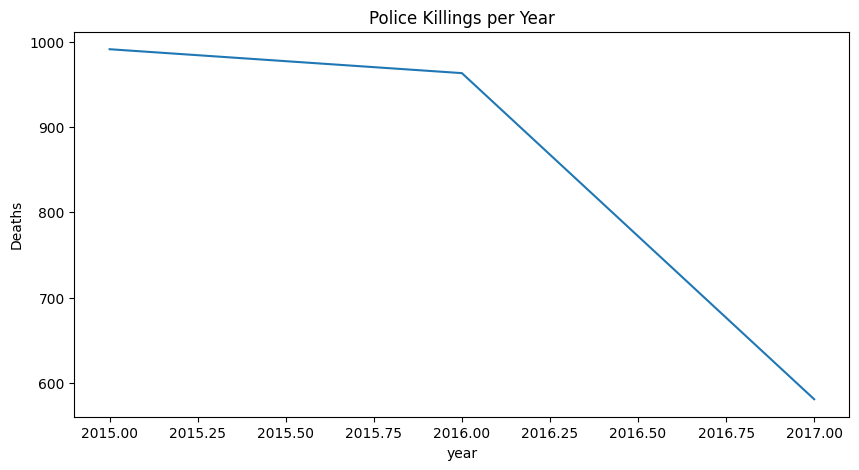

In [21]:
kills_per_year = df_fatalities.groupby('year').size()

kills_per_year.plot(figsize=(10,5), title='Police Killings per Year')
plt.ylabel('Deaths')
plt.show()

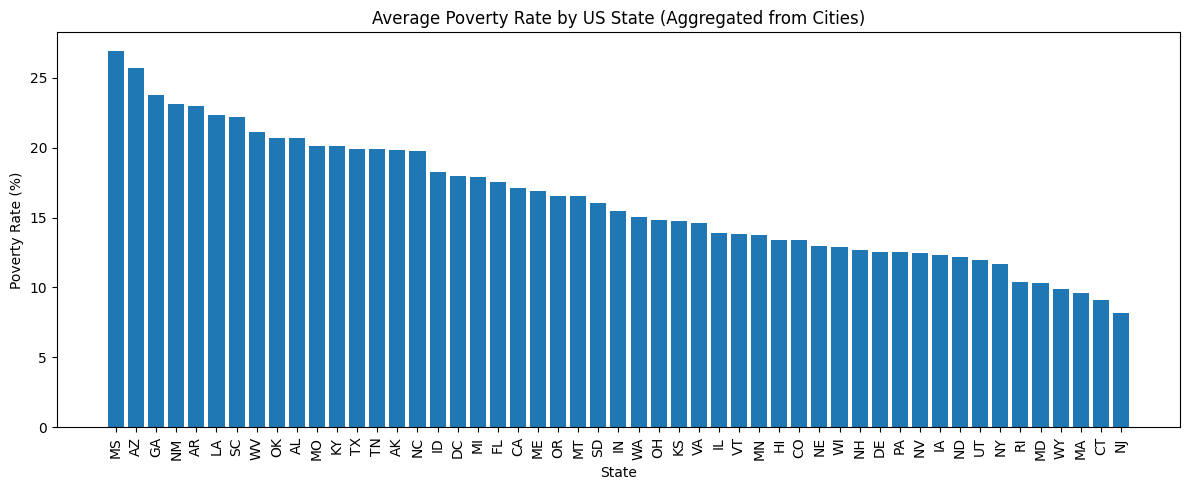

(Geographic Area      MS
 poverty_rate      26.88
 Name: 25, dtype: object,
 Geographic Area     NJ
 poverty_rate      8.19
 Name: 31, dtype: object)

In [22]:
# Ensure numeric
df_pct_poverty['poverty_rate'] = pd.to_numeric(df_pct_poverty['poverty_rate'], errors='coerce')

# Aggregate city-level to state-level (mean poverty rate)
poverty_by_state = (
    df_pct_poverty
    .groupby('Geographic Area', as_index=False)['poverty_rate']
    .mean()
    .sort_values('poverty_rate', ascending=False)
)

# Plot
plt.figure(figsize=(12,5))
plt.bar(poverty_by_state['Geographic Area'], poverty_by_state['poverty_rate'])
plt.xticks(rotation=90)
plt.title('Average Poverty Rate by US State (Aggregated from Cities)')
plt.ylabel('Poverty Rate (%)')
plt.xlabel('State')
plt.tight_layout()
plt.show()

# Highest and lowest
highest_poverty_state = poverty_by_state.iloc[0]
lowest_poverty_state = poverty_by_state.iloc[-1]

highest_poverty_state, lowest_poverty_state


# Chart the High School Graduation Rate by US State

Show the High School Graduation Rate in ascending order of US States. Which state has the lowest high school graduation rate? Which state has the highest?

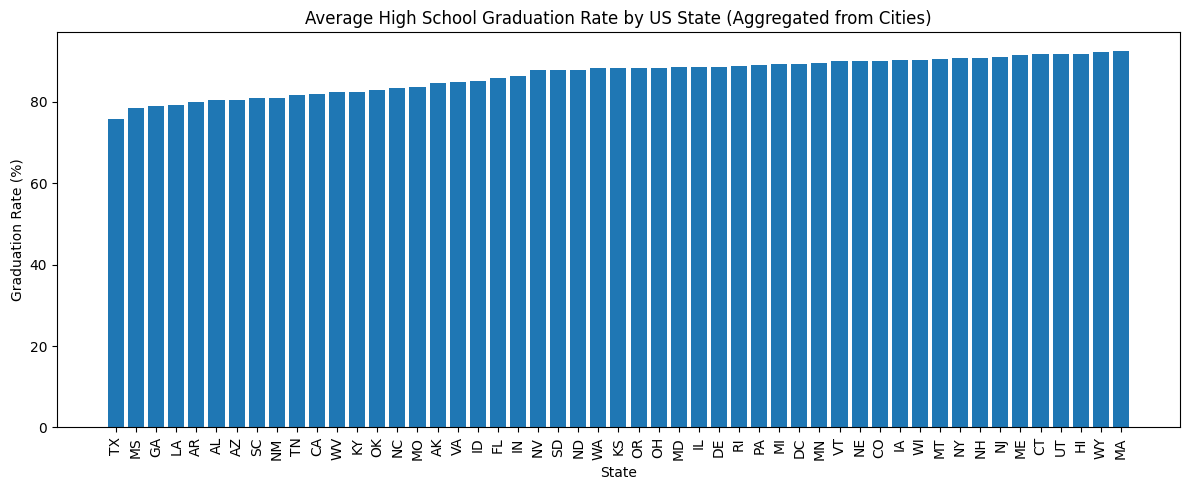

(Geographic Area           TX
 percent_completed_hs   75.69
 Name: 43, dtype: object,
 Geographic Area           MA
 percent_completed_hs   92.40
 Name: 19, dtype: object)

In [23]:
# Ensure numeric
df_pct_completed_hs['percent_completed_hs'] = pd.to_numeric(
    df_pct_completed_hs['percent_completed_hs'], errors='coerce'
)

# Aggregate city-level to state-level (mean graduation rate)
hs_by_state = (
    df_pct_completed_hs
    .groupby('Geographic Area', as_index=False)['percent_completed_hs']
    .mean()
    .sort_values('percent_completed_hs', ascending=True)
)

# Plot
plt.figure(figsize=(12,5))
plt.bar(hs_by_state['Geographic Area'], hs_by_state['percent_completed_hs'])
plt.xticks(rotation=90)
plt.title('Average High School Graduation Rate by US State (Aggregated from Cities)')
plt.ylabel('Graduation Rate (%)')
plt.xlabel('State')
plt.tight_layout()
plt.show()

# Lowest and highest
lowest_hs_state = hs_by_state.iloc[0]
highest_hs_state = hs_by_state.iloc[-1]

lowest_hs_state, highest_hs_state


# Visualise the Relationship between Poverty Rates and High School Graduation Rates

#### Create a line chart with two y-axes to show if the rations of poverty and high school graduation move together.  

In [24]:
# Ensure numeric
df_pct_poverty['poverty_rate'] = pd.to_numeric(df_pct_poverty['poverty_rate'], errors='coerce')
df_pct_completed_hs['percent_completed_hs'] = pd.to_numeric(df_pct_completed_hs['percent_completed_hs'], errors='coerce')

# Aggregate city-level to state-level
poverty_by_state = (
    df_pct_poverty.groupby('Geographic Area', as_index=False)['poverty_rate']
    .mean()
)

hs_by_state = (
    df_pct_completed_hs.groupby('Geographic Area', as_index=False)['percent_completed_hs']
    .mean()
)

# Merge on state
merged = pd.merge(poverty_by_state, hs_by_state, on='Geographic Area')

# Sort states by poverty (for a coherent line chart)
merged = merged.sort_values('poverty_rate')


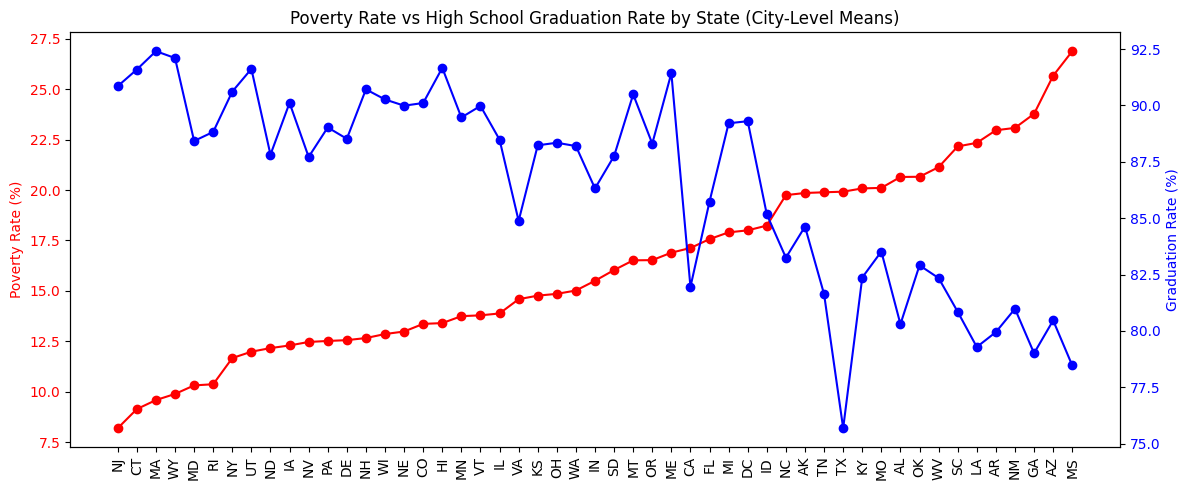

In [25]:
fig, ax1 = plt.subplots(figsize=(12,5))

# Poverty rate (left y-axis)
ax1.plot(merged['Geographic Area'], merged['poverty_rate'], color='red', marker='o', label='Poverty Rate')
ax1.set_ylabel('Poverty Rate (%)', color='red')
ax1.tick_params(axis='y', labelcolor='red')
ax1.tick_params(axis='x', rotation=90)

# Graduation rate (right y-axis)
ax2 = ax1.twinx()
ax2.plot(merged['Geographic Area'], merged['percent_completed_hs'], color='blue', marker='o', label='High School Graduation Rate')
ax2.set_ylabel('Graduation Rate (%)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title('Poverty Rate vs High School Graduation Rate by State (City-Level Means)')
plt.tight_layout()
plt.show()


#### Now use a Seaborn .jointplot() with a Kernel Density Estimate (KDE) and/or scatter plot to visualise the same relationship

In [26]:
# Ensure numeric
df_pct_poverty['poverty_rate'] = pd.to_numeric(df_pct_poverty['poverty_rate'], errors='coerce')
df_pct_completed_hs['percent_completed_hs'] = pd.to_numeric(df_pct_completed_hs['percent_completed_hs'], errors='coerce')

poverty_by_state = (
    df_pct_poverty.groupby('Geographic Area', as_index=False)['poverty_rate']
    .mean()
)

hs_by_state = (
    df_pct_completed_hs.groupby('Geographic Area', as_index=False)['percent_completed_hs']
    .mean()
)

merged = pd.merge(poverty_by_state, hs_by_state, on='Geographic Area')


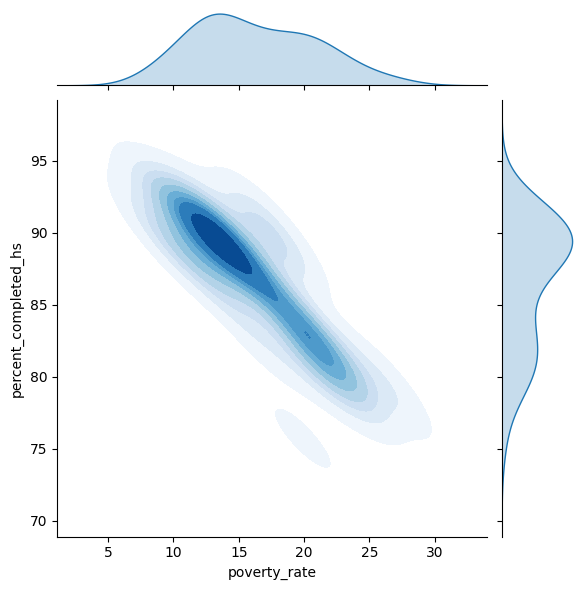

In [29]:
sns.jointplot(
    data=merged,
    x='poverty_rate',
    y='percent_completed_hs',
    kind='kde',
    fill=True,
    cmap='Blues'
)

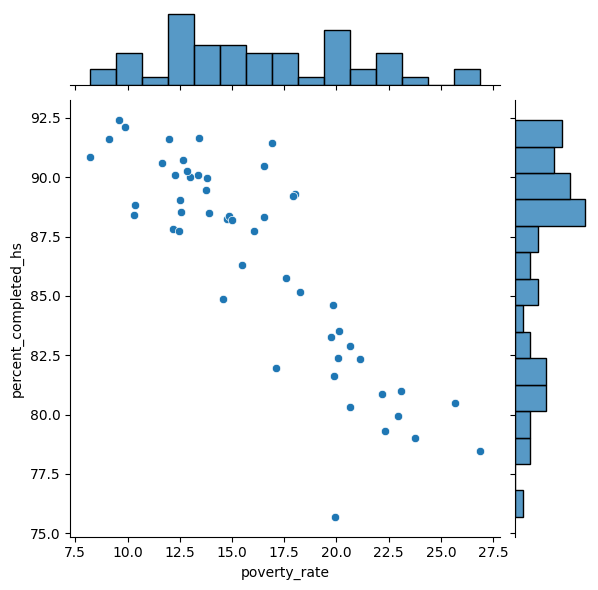

In [30]:
sns.jointplot(
    data=merged,
    x='poverty_rate',
    y='percent_completed_hs',
    kind='scatter',
    marginal_kws=dict(bins=15, fill=True)
)

#### Seaborn's `.lmplot()` or `.regplot()` to show a linear regression between the poverty ratio and the high school graduation ratio. 

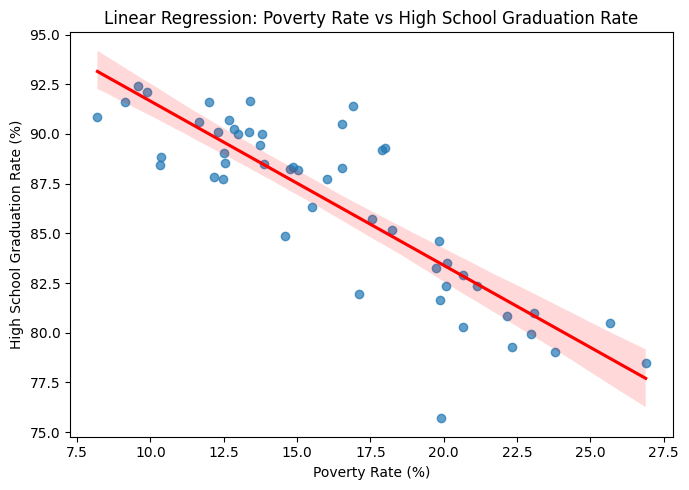

In [31]:
plt.figure(figsize=(7,5))
sns.regplot(
    data=merged,
    x='poverty_rate',
    y='percent_completed_hs',
    scatter_kws={'alpha': 0.7},
    line_kws={'color': 'red'}
)
plt.title('Linear Regression: Poverty Rate vs High School Graduation Rate')
plt.xlabel('Poverty Rate (%)')
plt.ylabel('High School Graduation Rate (%)')
plt.tight_layout()
plt.show()

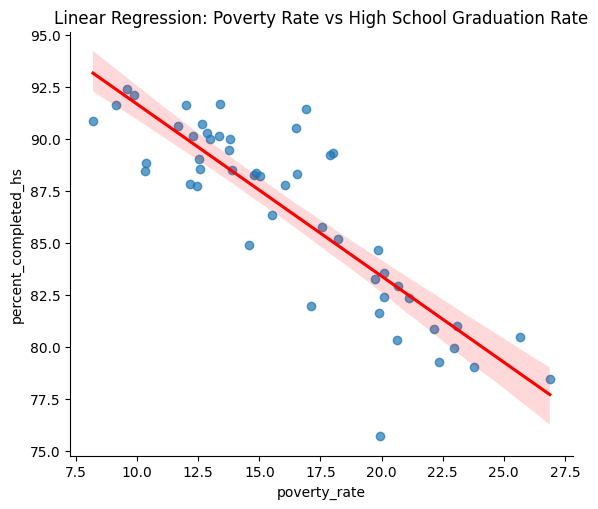

In [32]:
sns.lmplot(
    data=merged,
    x='poverty_rate',
    y='percent_completed_hs',
    height=5,
    aspect=1.2,
    scatter_kws={'alpha': 0.7},
    line_kws={'color': 'red'}
)
plt.title('Linear Regression: Poverty Rate vs High School Graduation Rate')
plt.show()

# Create a Bar Chart with Subsections Showing the Racial Makeup of Each US State

Visualise the share of the white, black, hispanic, asian and native american population in each US State using a bar chart with sub sections. 

In [33]:
# Ensure numeric
race_cols = [
    'share_white', 'share_black', 'share_hispanic',
    'share_asian', 'share_native_american'
]

for col in race_cols:
    df_share_race_city[col] = pd.to_numeric(df_share_race_city[col], errors='coerce')

# Aggregate city-level shares to state-level (mean)
race_by_state = (
    df_share_race_city
    .groupby('Geographic area', as_index=False)[race_cols]
    .mean()
)

race_by_state.head()

,Geographic area,share_white,share_black,share_hispanic,share_asian,share_native_american
0,AK,45.65,0.57,2.15,1.39,45.86
1,AL,72.51,23.32,2.98,0.48,0.66
2,AR,78.45,16.30,4.27,0.48,0.76
3,AZ,59.93,0.95,20.14,0.73,28.59
4,CA,71.87,2.69,29.65,5.57,1.72


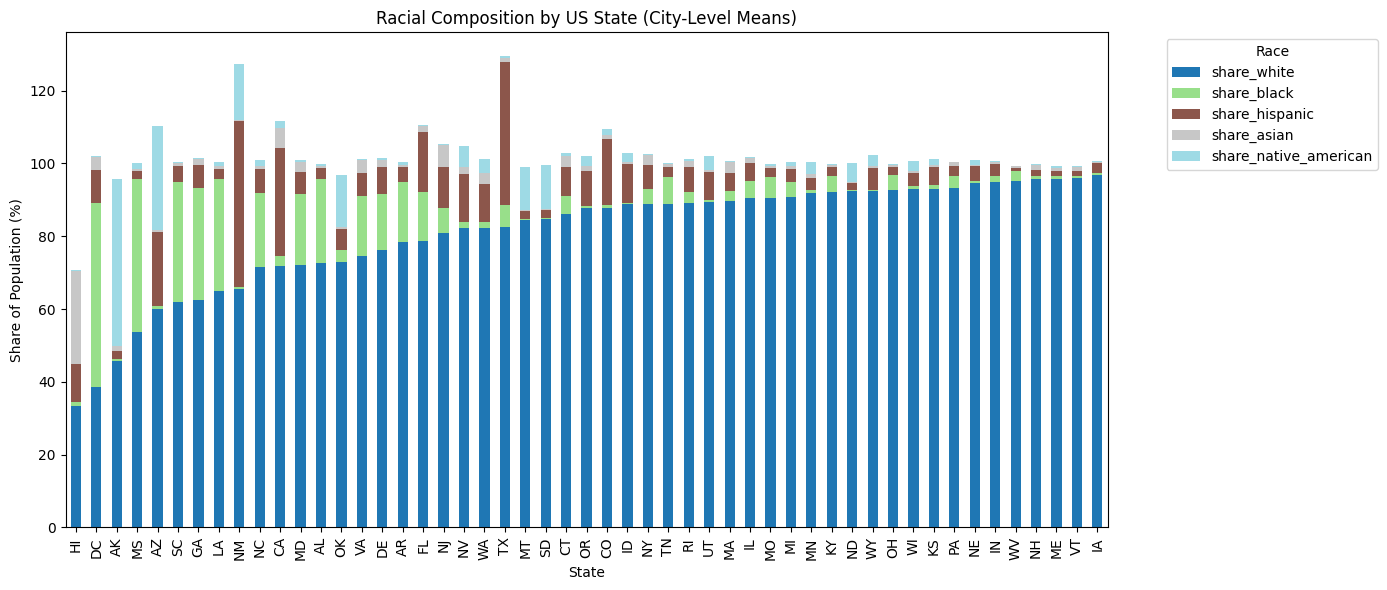

In [34]:
race_by_state_sorted = race_by_state.sort_values('share_white')  # sort for visual clarity

race_by_state_sorted.set_index('Geographic area')[race_cols].plot(
    kind='bar',
    stacked=True,
    figsize=(14,6),
    colormap='tab20'
)

plt.title('Racial Composition by US State (City-Level Means)')
plt.xlabel('State')
plt.ylabel('Share of Population (%)')
plt.xticks(rotation=90)
plt.legend(title='Race', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# Create Donut Chart by of People Killed by Race

Hint: Use `.value_counts()`

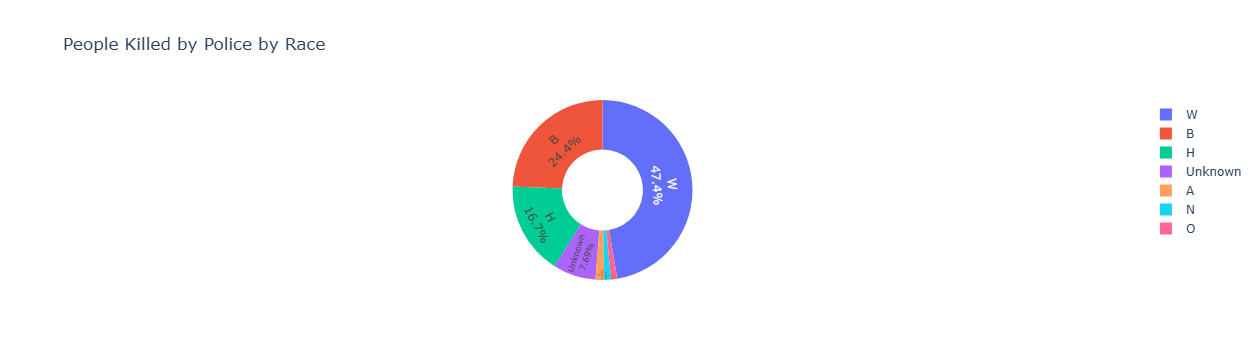

In [35]:
race_counts = (
    df_fatalities['race']
    .replace({0: 'Unknown', '0': 'Unknown'})
    .fillna('Unknown')
    .value_counts()
    .reset_index()
)

race_counts.columns = ['Race', 'Count']

fig = px.pie(
    race_counts,
    names='Race',
    values='Count',
    hole=0.45,
    title='People Killed by Police by Race'
)

fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()

# Create a Chart Comparing the Total Number of Deaths of Men and Women

Use `df_fatalities` to illustrate how many more men are killed compared to women. 

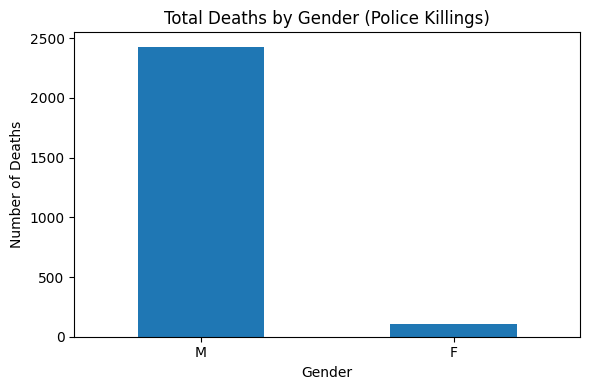

gender
M    2428
F     107
Name: count, dtype: int64

In [36]:
gender_counts = (
    df_fatalities['gender']
    .replace({0: 'Unknown', '0': 'Unknown'})
    .fillna('Unknown')
    .value_counts()
)

plt.figure(figsize=(6,4))
gender_counts.plot(kind='bar')
plt.title('Total Deaths by Gender (Police Killings)')
plt.xlabel('Gender')
plt.ylabel('Number of Deaths')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

gender_counts

# Create a Box Plot Showing the Age and Manner of Death

Break out the data by gender using `df_fatalities`. Is there a difference between men and women in the manner of death? 

In [37]:
# Ensure age is numeric
df_fatalities['age'] = pd.to_numeric(df_fatalities['age'], errors='coerce')

# Clean gender labels
df_fatalities['gender'] = (
    df_fatalities['gender']
    .replace({0: 'Unknown', '0': 'Unknown'})
    .fillna('Unknown')
)

# Clean manner_of_death labels
df_fatalities['manner_of_death'] = (
    df_fatalities['manner_of_death']
    .replace({0: 'Unknown', '0': 'Unknown'})
    .fillna('Unknown')
)


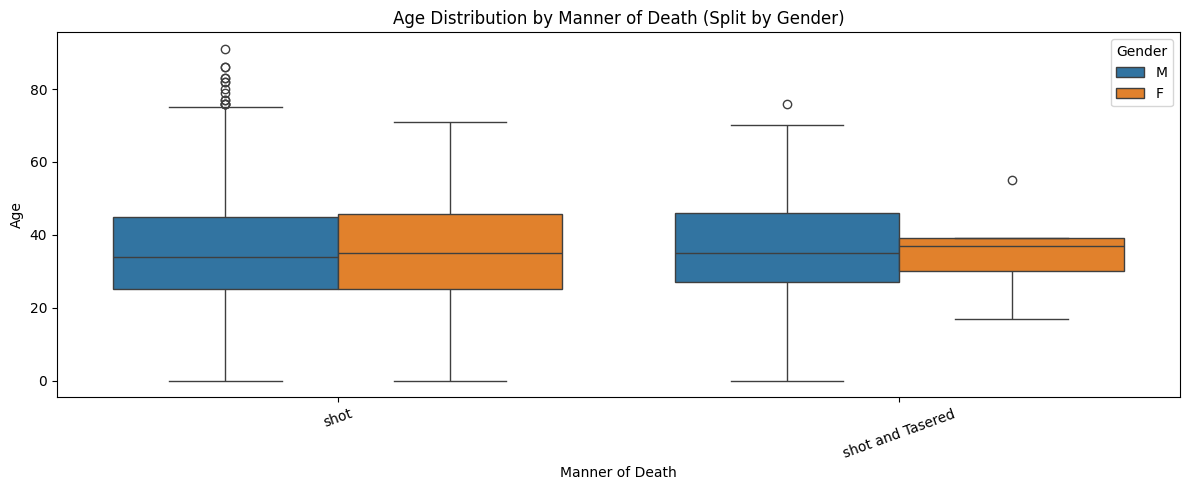

In [38]:
plt.figure(figsize=(12,5))
sns.boxplot(
    data=df_fatalities.dropna(subset=['age']),
    x='manner_of_death',
    y='age',
    hue='gender'
)
plt.title('Age Distribution by Manner of Death (Split by Gender)')
plt.xlabel('Manner of Death')
plt.ylabel('Age')
plt.xticks(rotation=20)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()


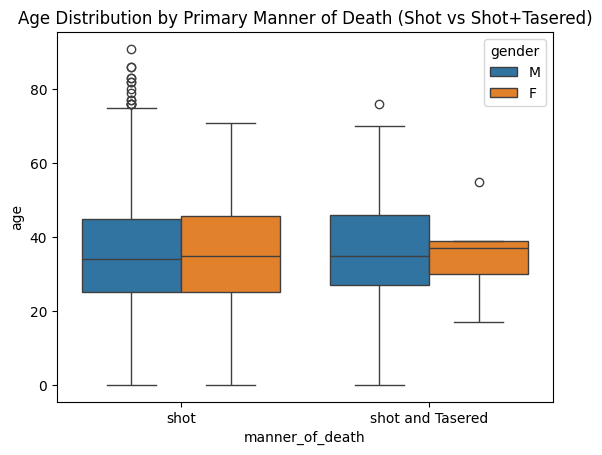

In [39]:
common_methods = ['shot', 'shot and Tasered']
filtered = df_fatalities[df_fatalities['manner_of_death'].isin(common_methods)]

sns.boxplot(
    data=filtered.dropna(subset=['age']),
    x='manner_of_death',
    y='age',
    hue='gender'
)
plt.title('Age Distribution by Primary Manner of Death (Shot vs Shot+Tasered)')
plt.show()


# Were People Armed? 

In what percentage of police killings were people armed? Create chart that show what kind of weapon (if any) the deceased was carrying. How many of the people killed by police were armed with guns versus unarmed? 

In [40]:
df_fatalities['armed_clean'] = (
    df_fatalities['armed']
    .replace({0: 'Unknown', '0': 'Unknown'})
    .fillna('Unknown')
    .str.lower()
    .str.strip()
)

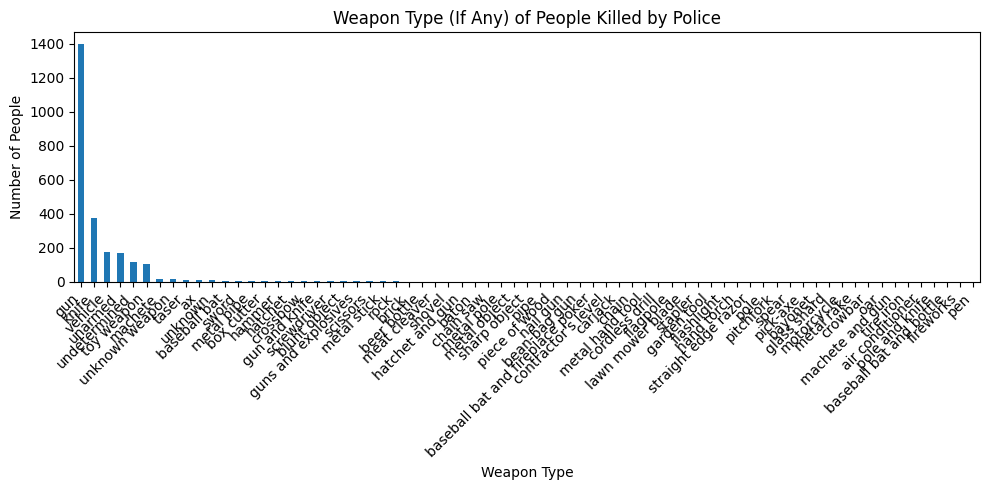

armed_clean
gun                        1398
knife                       373
vehicle                     177
unarmed                     171
undetermined                117
                           ... 
air conditioner               1
pole and knife                1
baseball bat and bottle       1
fireworks                     1
pen                           1
Name: count, Length: 69, dtype: int64

In [41]:
weapon_counts = df_fatalities['armed_clean'].value_counts()

plt.figure(figsize=(10,5))
weapon_counts.plot(kind='bar')
plt.title('Weapon Type (If Any) of People Killed by Police')
plt.xlabel('Weapon Type')
plt.ylabel('Number of People')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

weapon_counts

In [42]:
is_armed = ~df_fatalities['armed_clean'].isin(['unarmed', 'unknown'])

armed_pct = is_armed.mean() * 100
unarmed_pct = 100 - armed_pct

armed_pct, unarmed_pct

(np.float64(92.89940828402366), np.float64(7.100591715976336))

In [43]:
guns_vs_unarmed = df_fatalities['armed_clean'].isin(['gun']).value_counts()

guns_vs_unarmed

armed_clean
True     1398
False    1137
Name: count, dtype: int64

In [44]:
guns_count = (df_fatalities['armed_clean'] == 'gun').sum()
unarmed_count = (df_fatalities['armed_clean'] == 'unarmed').sum()

guns_count, unarmed_count

(np.int64(1398), np.int64(171))

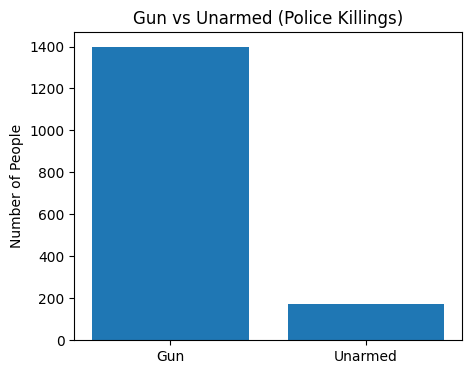

In [45]:
plt.figure(figsize=(5,4))
plt.bar(['Gun', 'Unarmed'], [guns_count, unarmed_count])
plt.title('Gun vs Unarmed (Police Killings)')
plt.ylabel('Number of People')
plt.show()

# How Old Were the People Killed?

Work out what percentage of people killed were under 25 years old.

In [46]:
# Ensure numeric age
df_fatalities['age'] = pd.to_numeric(df_fatalities['age'], errors='coerce')

under_25_pct = (
    df_fatalities['age']
    .dropna()
    .lt(25)
    .mean() * 100
)

under_25_pct


np.float64(20.78895463510848)

Create a histogram and KDE plot that shows the distribution of ages of the people killed by police. 

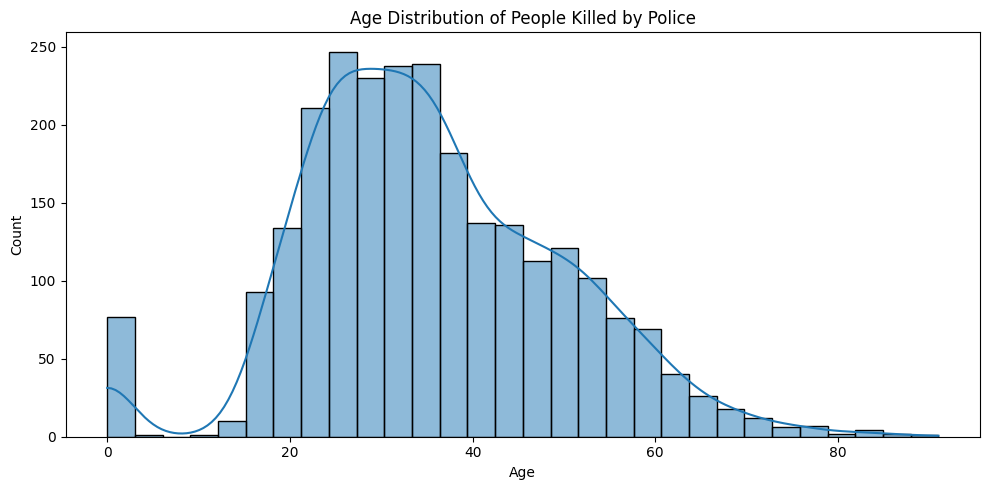

In [47]:
plt.figure(figsize=(10,5))
sns.histplot(
    data=df_fatalities.dropna(subset=['age']),
    x='age',
    bins=30,
    kde=True
)
plt.title('Age Distribution of People Killed by Police')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


Create a seperate KDE plot for each race. Is there a difference between the distributions? 

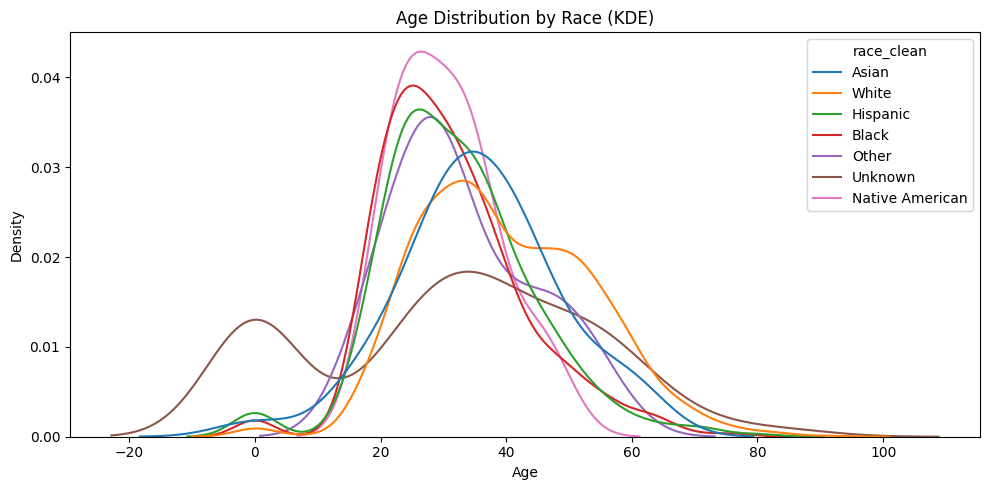

In [49]:
race_map = {
    'W': 'White',
    'B': 'Black',
    'H': 'Hispanic',
    'A': 'Asian',
    'N': 'Native American',
    'O': 'Other',
    0: 'Unknown',
    '0': 'Unknown'
}

df_fatalities['race_clean'] = df_fatalities['race'].map(race_map).fillna('Unknown')

plt.figure(figsize=(10,5))
sns.kdeplot(
    data=df_fatalities.dropna(subset=['age']),
    x='age',
    hue='race_clean',
    common_norm=False
)
plt.title('Age Distribution by Race (KDE)')
plt.xlabel('Age')
plt.ylabel('Density')
plt.tight_layout()
plt.show()


# Race of People Killed

Create a chart that shows the total number of people killed by race. 

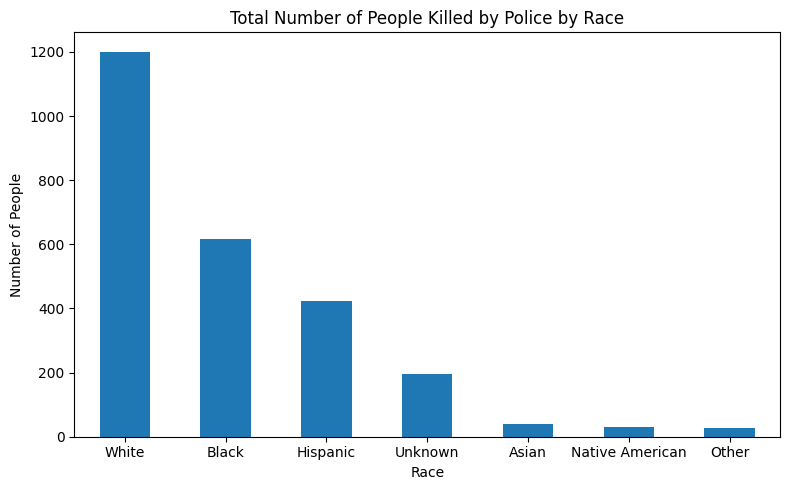

race_clean
White              1201
Black               618
Hispanic            423
Unknown             195
Asian                39
Native American      31
Other                28
Name: count, dtype: int64

In [50]:
# Clean race labels (map short codes to readable names)
race_map = {
    'W': 'White',
    'B': 'Black',
    'H': 'Hispanic',
    'A': 'Asian',
    'N': 'Native American',
    'O': 'Other',
    0: 'Unknown',
    '0': 'Unknown'
}

df_fatalities['race_clean'] = df_fatalities['race'].map(race_map).fillna('Unknown')

race_counts = df_fatalities['race_clean'].value_counts()

plt.figure(figsize=(8,5))
race_counts.plot(kind='bar')
plt.title('Total Number of People Killed by Police by Race')
plt.xlabel('Race')
plt.ylabel('Number of People')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

race_counts


# Mental Illness and Police Killings

What percentage of people killed by police have been diagnosed with a mental illness?

In [51]:
# Ensure boolean (handles any 0/1 or string issues)
df_fatalities['signs_of_mental_illness'] = df_fatalities['signs_of_mental_illness'].astype(bool)

mental_illness_pct = (
    df_fatalities['signs_of_mental_illness']
    .mean() * 100
)

mental_illness_pct

np.float64(24.970414201183434)

# In Which Cities Do the Most Police Killings Take Place?

Create a chart ranking the top 10 cities with the most police killings. Which cities are the most dangerous?  

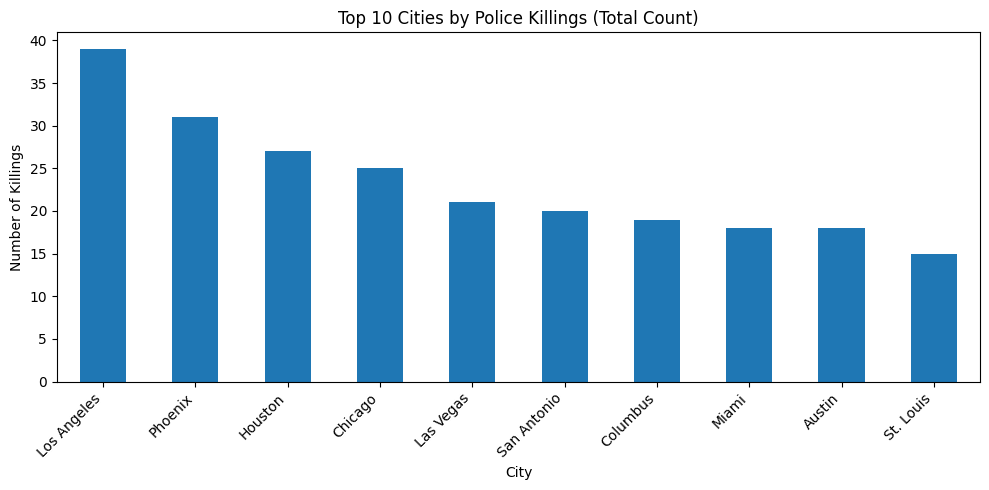

city
Los Angeles    39
Phoenix        31
Houston        27
Chicago        25
Las Vegas      21
San Antonio    20
Columbus       19
Miami          18
Austin         18
St. Louis      15
Name: count, dtype: int64

In [52]:
top_cities = (
    df_fatalities['city']
    .replace({0: 'Unknown', '0': 'Unknown'})
    .fillna('Unknown')
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))
top_cities.plot(kind='bar')
plt.title('Top 10 Cities by Police Killings (Total Count)')
plt.xlabel('City')
plt.ylabel('Number of Killings')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

top_cities

# Rate of Death by Race

Find the share of each race in the top 10 cities. Contrast this with the top 10 cities of police killings to work out the rate at which people are killed by race for each city. 

In [53]:
top_cities = (
    df_fatalities['city']
    .replace({0: 'Unknown', '0': 'Unknown'})
    .fillna('Unknown')
    .value_counts()
    .head(10)
    .index
    .tolist()
)

top_cities

['Los Angeles',
 'Phoenix',
 'Houston',
 'Chicago',
 'Las Vegas',
 'San Antonio',
 'Columbus',
 'Miami',
 'Austin',
 'St. Louis']

In [54]:
# Clean race labels
race_map = {
    'W': 'White',
    'B': 'Black',
    'H': 'Hispanic',
    'A': 'Asian',
    'N': 'Native American',
    'O': 'Other',
    0: 'Unknown',
    '0': 'Unknown'
}

df_fatalities['race_clean'] = df_fatalities['race'].map(race_map).fillna('Unknown')

deaths_by_city_race = (
    df_fatalities[df_fatalities['city'].isin(top_cities)]
    .groupby(['city', 'race_clean'])
    .size()
    .reset_index(name='deaths')
)

deaths_by_city_race.head()


,city,race_clean,deaths
0,Austin,Black,3
1,Austin,Hispanic,2
2,Austin,White,13
3,Chicago,Black,21
4,Chicago,Hispanic,1


In [55]:
# Normalize column names for join
df_share_race_city['City_clean'] = df_share_race_city['City'].str.strip().str.lower()
deaths_by_city_race['City_clean'] = deaths_by_city_race['city'].str.strip().str.lower()

race_cols = ['share_white', 'share_black', 'share_hispanic', 'share_asian', 'share_native_american']

city_race_share = df_share_race_city[['City', *race_cols]].copy()
city_race_share['City_clean'] = city_race_share['City'].str.strip().str.lower()

# Keep only top 10 cities
city_race_share_top10 = city_race_share[city_race_share['City_clean'].isin(deaths_by_city_race['City_clean'].unique())]

city_race_share_top10.head()

,City,share_white,share_black,share_hispanic,share_asian,share_native_american,City_clean


In [56]:
# Pivot deaths to wide format
deaths_pivot = deaths_by_city_race.pivot(index='City_clean', columns='race_clean', values='deaths').fillna(0)

# Normalize to percentage of deaths
deaths_pct = deaths_pivot.div(deaths_pivot.sum(axis=1), axis=0) * 100

# Align population shares
pop_shares = (
    city_race_share_top10
    .set_index('City_clean')[race_cols]
    .rename(columns={
        'share_white': 'White',
        'share_black': 'Black',
        'share_hispanic': 'Hispanic',
        'share_asian': 'Asian',
        'share_native_american': 'Native American'
    })
)

# Compare (Deaths % - Population %)
disparity = deaths_pct[['White','Black','Hispanic','Asian','Native American']] - pop_shares

disparity.round(2)

race_clean,White,Black,Hispanic,Asian,Native American
City_clean,,,,,
austin,NaN,NaN,NaN,NaN,NaN
chicago,NaN,NaN,NaN,NaN,NaN
columbus,NaN,NaN,NaN,NaN,NaN
houston,NaN,NaN,NaN,NaN,NaN
las vegas,NaN,NaN,NaN,NaN,NaN
los angeles,NaN,NaN,NaN,NaN,NaN
miami,NaN,NaN,NaN,NaN,NaN
phoenix,NaN,NaN,NaN,NaN,NaN
san antonio,NaN,NaN,NaN,NaN,NaN


# Create a Choropleth Map of Police Killings by US State

Which states are the most dangerous? Compare your map with your previous chart. Are these the same states with high degrees of poverty? 

In [57]:
# Clean state codes
df_fatalities['state_clean'] = (
    df_fatalities['state']
    .replace({0: 'Unknown', '0': 'Unknown'})
    .fillna('Unknown')
)

# Aggregate killings by state
killings_by_state = (
    df_fatalities
    .groupby('state_clean')
    .size()
    .reset_index(name='killings')
)

killings_by_state.head()

,state_clean,killings
0,AK,15
1,AL,50
2,AR,26
3,AZ,118
4,CA,424


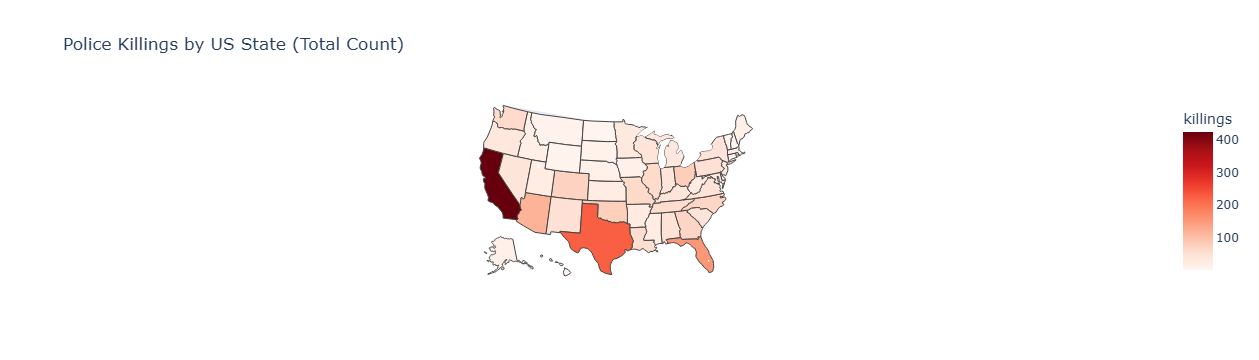

In [58]:
fig = px.choropleth(
    killings_by_state,
    locations='state_clean',
    locationmode='USA-states',
    color='killings',
    color_continuous_scale='Reds',
    scope='usa',
    title='Police Killings by US State (Total Count)'
)

fig.show()

# Number of Police Killings Over Time

Analyse the Number of Police Killings over Time. Is there a trend in the data? 

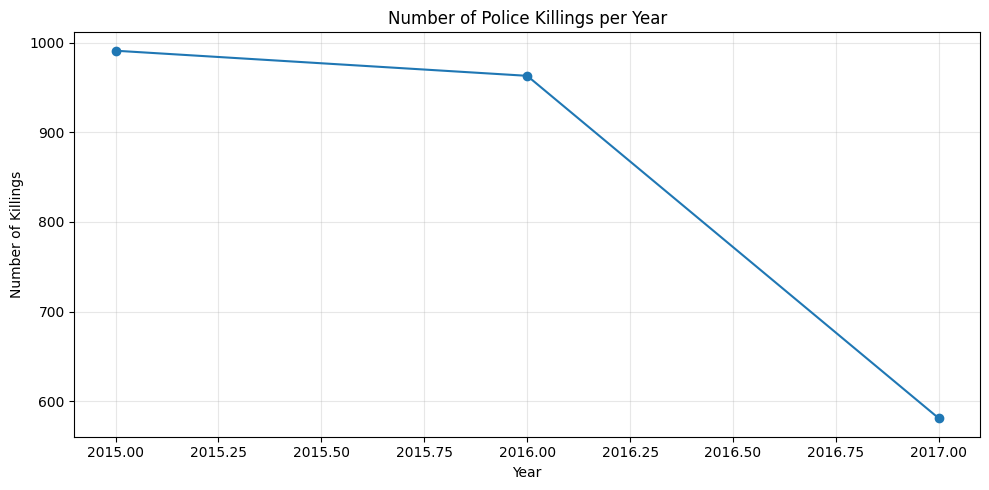

year
2015    991
2016    963
2017    581
dtype: int64

In [59]:
# Ensure date is parsed (you already fixed this)
df_fatalities['year'] = df_fatalities['date'].dt.year

kills_per_year = df_fatalities.groupby('year').size()

plt.figure(figsize=(10,5))
kills_per_year.plot(kind='line', marker='o')
plt.title('Number of Police Killings per Year')
plt.xlabel('Year')
plt.ylabel('Number of Killings')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

kills_per_year

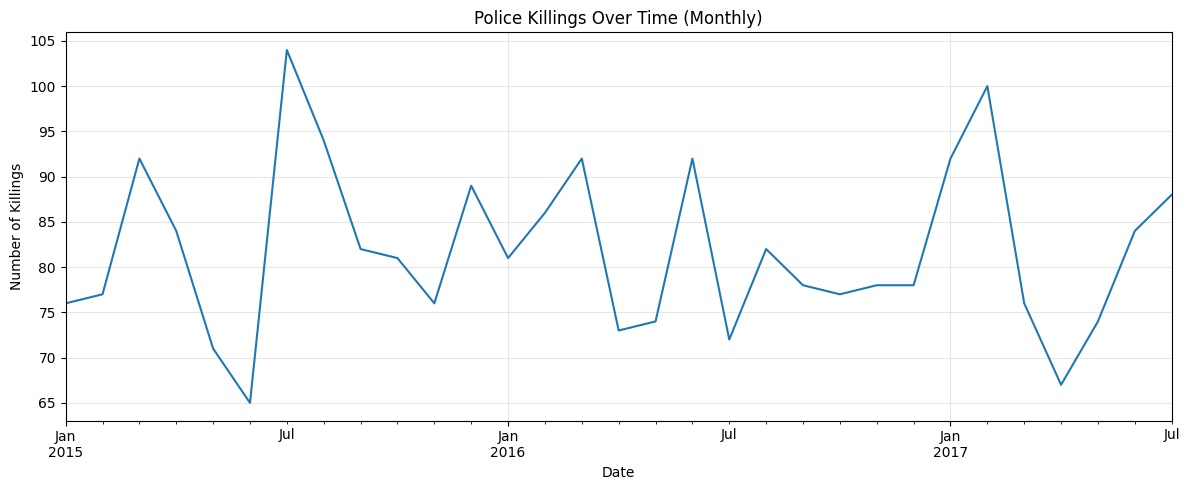

In [60]:
df_fatalities['year_month'] = df_fatalities['date'].dt.to_period('M').dt.to_timestamp()

kills_per_month = df_fatalities.groupby('year_month').size()

plt.figure(figsize=(12,5))
kills_per_month.plot(kind='line')
plt.title('Police Killings Over Time (Monthly)')
plt.xlabel('Date')
plt.ylabel('Number of Killings')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Epilogue

Now that you have analysed the data yourself, read [The Washington Post's analysis here](https://www.washingtonpost.com/graphics/investigations/police-shootings-database/).